# Pairs Trading & Statistical Arbitrage
## 01 - Data Collection

This notebook pulls historical price data for Visa (V) and Mastercard (MA) and prepares it for pairs trading analysis.

### Why Visa and Mastercard?
V and MA operate nearly identical business models, payment network duopolies with no direct credit risk on their balance sheets. Both firms face the same fundamental drivers: consumer spending volumes, interchange fee regulation, and digital payments adoption. This shared economic structure makes them strong candidates for cointegration, their prices may drift individually but should maintain a stable long run equilibrium relationship.

### Why Cointegration?
Both price series are non-stationary, they trend upward over time with no fixed mean. Standard correlation would be misleading here due to the risk of spurious regression, a concept from econometrics where two unrelated trending series appear correlated simply because they both trend. Cointegration is the formal test for whether the relationship between two non-stationary series is real and stable rather than spurious.

### Data
We pull daily adjusted closing prices from 2010 to present using Yahoo Finance, giving us a long enough history to estimate a stable hedge ratio and test for cointegration robustly.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pull adjusted closing prices for Visa and Mastercard
tickers = ["V", "MA"]

raw = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices = raw.dropna()

print(f"Price data: {prices.shape[0]} days, {prices.shape[1]} tickers")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"\nSample:")
print(prices.tail())

[*********************100%***********************]  2 of 2 completed

Price data: 4136 days, 2 tickers
Date range: 2010-01-04 to 2026-06-12

Sample:
Ticker              MA           V
Date                              
2026-06-08  485.670013  319.670013
2026-06-09  495.239990  325.049988
2026-06-10  489.079987  322.959991
2026-06-11  486.510010  319.049988
2026-06-12  489.980011  322.390015


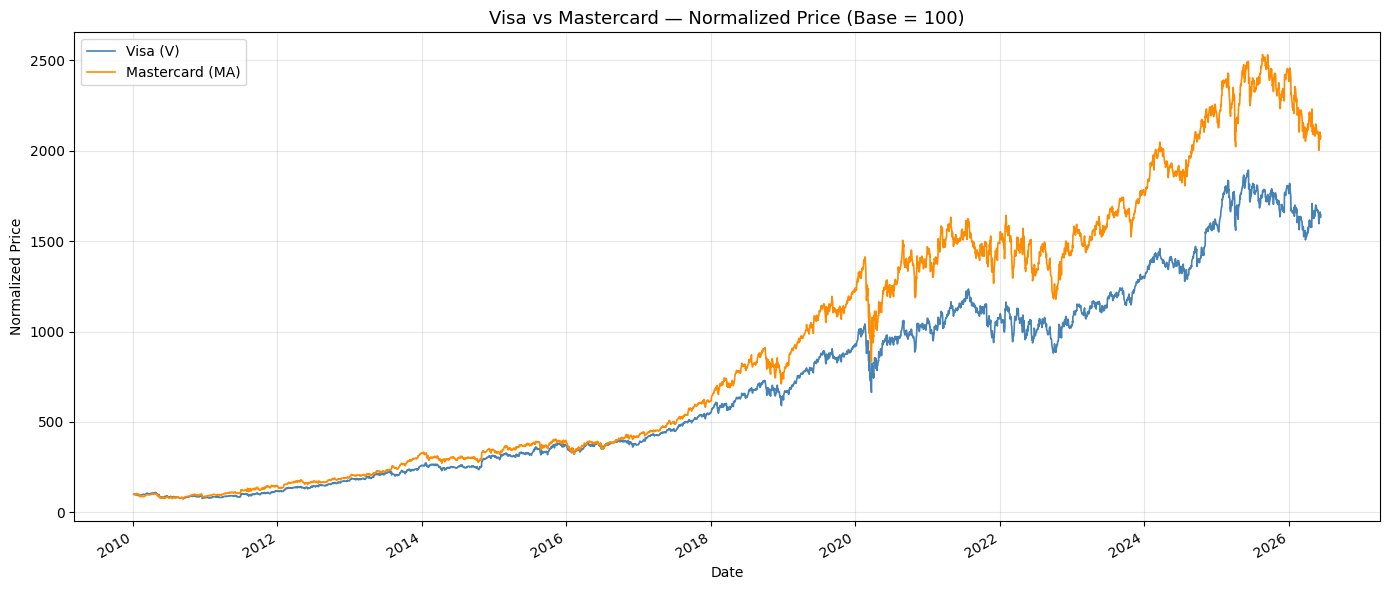

In [4]:
# Normalize to 100 at start so both series are on the same scale
normalized = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))

normalized["V"].plot(ax=ax, color="steelblue", linewidth=1.2, label="Visa (V)")
normalized["MA"].plot(ax=ax, color="darkorange", linewidth=1.2, label="Mastercard (MA)")

ax.set_title("Visa vs Mastercard — Normalized Price (Base = 100)", fontsize=13)
ax.set_ylabel("Normalized Price")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()